In [62]:
import numpy as np
import matplotlib.pyplot as plt

In [63]:
from Losses import BaseLoss, HalfSquaredError, AbsoluteError

In [64]:
from sklearn.base import RegressorMixin, BaseEstimator
from sklearn.utils.validation import validate_data, check_is_fitted


class BaseLinearRegression(RegressorMixin, BaseEstimator):
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
    def predict(self, X):
        check_is_fitted(self)
        X = validate_data(
            self,
            X,
            reset=False,
            dtype=float,
        )
        predictions = X@self.coef_ + self.intercept_
        return predictions

In [65]:
class MyLinearRegressionClosedForm(BaseLinearRegression):
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one, X),axis = 1)
        else:
            ones_X = X
        weights = np.linalg.lstsq(ones_X,y,rcond = None)[0]
        if self.fit_intercept:
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ = 0
            self.coef_ = weights
        return self

In [66]:
LOSS_FUNCTION = {
                 'half_square_error': HalfSquaredError,
                 'absolute_error': AbsoluteError}
class BaseLinearRegressionGD(BaseLinearRegression):
    def __init__(self, fit_intercept = True, loss_function = 'half_square_error'):
        super().__init__(fit_intercept= fit_intercept)
        self.loss_function = loss_function
    def _resolve_loss(self):
        if isinstance(self.loss_function, str):
            if self.loss_function not in LOSS_FUNCTION:
                raise ValueError("Unsupported loss functions")
            return LOSS_FUNCTION[self.loss_function]()
        if isinstance(self.loss_function, BaseLoss):
            return self.loss_function

In [67]:
class MyLinearRegressionBatchGD(BaseLinearRegressionGD):
    def __init__(self,fit_intercept = True, num_epochs = 100,learning_rate = 0.01, loss_function = "half_square_error"):
        super().__init__(fit_intercept = fit_intercept,
                         loss_function=loss_function)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
    def fit(self,X,y):
        self.loss_function_ = self._resolve_loss()

        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one, X),axis = 1)
        else:
            ones_X = X

        weights = np.zeros(ones_X.shape[1])
        self.loss_history_ = []

        for i in range(self.num_epochs):
            y_pred = ones_X @ weights
            loss = self.loss_function_(y, y_pred)
            self.loss_history_.append(loss)
            dW = ones_X.T @ self.loss_function_.gradient(y, y_pred)
            weights -= self.learning_rate * dW
            print(f"Epochs {i} || Loss: {loss}")
        if self.fit_intercept:
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ = 0
            self.coef_ = weights
        return self
class MyLinearRegressionMiniBatchGD(BaseLinearRegressionGD):
    def __init__(self,random_state = None,fit_intercept = True, num_epochs = 100, learning_rate = 0.01, batch_size = 32, loss_function = "half_square_error"):
        super().__init__(fit_intercept = fit_intercept,
                         loss_function=loss_function)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.random_state = random_state
    def fit(self, X, y):
        self.loss_function_ = self._resolve_loss()
        if (self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one,X), axis = 1)
        else:
            ones_X = X
        weights = np.zeros(ones_X.shape[1])
        self.batch_loss_history_ = []
        rng = np.random.default_rng(self.random_state)
        for i in range(self.num_epochs):

            permutations = rng.permutation(ones_X.shape[0])
            ones_X_shuffle = ones_X[permutations]
            y_shuffle = y[permutations]

            for start in range(0, X.shape[0] , self.batch_size):
                end = start + self.batch_size
                X_batch = ones_X_shuffle[start: end]
                y_batch = y_shuffle[start: end]

                y_pred = X_batch @ weights
                loss = self.loss_function_(y_batch, y_pred)
                self.batch_loss_history_.append(loss)

                dw = X_batch.T @ self.loss_function_.gradient(y_batch, y_pred)
                weights -= dw * self.learning_rate
        if(self.fit_intercept):
            self.intercept_ = weights[0]
            self.coef_ = weights[1:]
        else:
            self.intercept_ =  0
            self.coef_= weights
        return self
class MyLinearRegressionSGD(BaseLinearRegressionGD):
    def __init__(self,fit_intercept = True, num_epochs = 100, learning_rate = 0.01, loss_function = 'half_square_error'):
        super().__init__(fit_intercept = fit_intercept,
                         loss_function=loss_function)
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
    def fit(self,X,y):
        if(self.fit_intercept):
            one = np.ones((X.shape[0],1))
            ones_X = np.concatenate((one,X) , axis = 1)
        else:
            ones_X = X

        weights = np.zeros(ones_X.shape[1])
        self.loss_history_= []

        self.loss_function_ = self._resolve_loss()
        for i in range(self.num_epochs):
            for j in range(ones_X.shape[0]):
                X_sample = ones_X[j:j+1]
                y_sample = y[j:j+1]
                y_pred = X_sample @ weights
                loss = self.loss_function_(y_sample, y_pred)
                self.loss_history_.append(loss)
                dw = X_sample @ self.loss_function_.gradient(y_sample, y_pred)
                weights -= self.learning_rate*dw
        if(self.fit_intercept):
            self.coef_ = weights[1:]
            self.intercept_ = weights[0]
        else:
            self.coef_ = weights
            self.intercept_ = 0
        return self

In [68]:
class MyStandardScaler():
    def __init__(self):
        self.mean_ = None
        self.scale_ = None
    def fit(self,data):
        self.mean_ = data.mean(axis = 0)
        self.scale_ = data.std(axis = 0)
        self.scale_[np.where(self.scale_ == 0)] = 1
        return self
    def transform(self,data):
        if self.mean_ is None or self.scale_ is None:
            raise RuntimeError("Scaler chưa được fit !!!")
        return (data - self.mean_) / self.scale_
    def fit_transform(self,data):
        return self.fit(data).transform(data)
    def reverse_transform(self,data):
        if self.mean_ is None or self.scale_ is None:
            raise RuntimeError("Scaler chưa được fit !!!")
        return data * self.scale_ + self.mean_

Epochs 0 || Loss: 16.833333333333332
Epochs 1 || Loss: 16.554556285714284
Epochs 2 || Loss: 16.280999910298284
Epochs 3 || Loss: 16.01256134396113
Epochs 4 || Loss: 15.749139799280265
Epochs 5 || Loss: 15.490636521868975
Epochs 6 || Loss: 15.236954748607513
Epochs 7 || Loss: 14.98799966675167
Epochs 8 || Loss: 14.743678373899762
Epochs 9 || Loss: 14.50389983879952
Epochs 10 || Loss: 14.268574862976587
Epochs 11 || Loss: 14.037616043166992
Epochs 12 || Loss: 13.810937734536175
Epochs 13 || Loss: 13.588456014667571
Epochs 14 || Loss: 13.370088648304261
Epochs 15 || Loss: 13.155755052827377
Epochs 16 || Loss: 12.94537626445548
Epochs 17 || Loss: 12.738874905149373
Epochs 18 || Loss: 12.536175150207242
Epochs 19 || Loss: 12.337202696535282
Epochs 20 || Loss: 12.141884731579333
Epochs 21 || Loss: 11.9501499029034
Epochs 22 || Loss: 11.76192828840118
Epochs 23 || Loss: 11.577151367127081
Epochs 24 || Loss: 11.395751990733517
Epochs 25 || Loss: 11.21766435550147
Epochs 26 || Loss: 11.04282397

Text(0, 0.5, 'Loss')

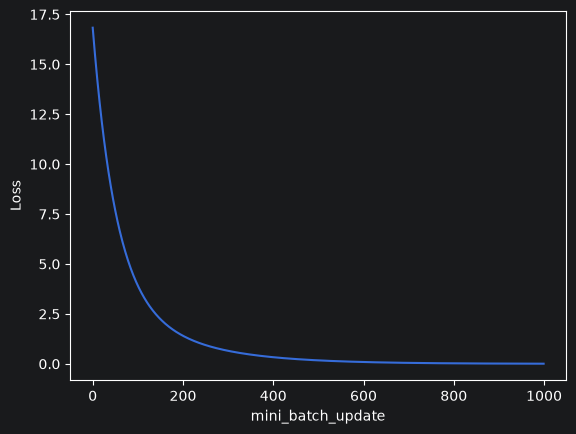

In [69]:
X = np.array([
    [1.0, 2.0],
    [2.0, 0.0],
    [3.0, 1.0],
    [4.0, 3.0],
    [5.0, 2.0],
    [6.0, 4.0],
])

y = (
    2 * X[:, 0]
    - 3 * X[:, 1]
    + 4
)
scaler_X = MyStandardScaler()
X = scaler_X.fit_transform(X)
model = MyLinearRegressionBatchGD(num_epochs=1000)
model.fit(X,y)
print(model.coef_, model.intercept_)
plt.plot(model.loss_history_)
plt.xlabel("mini_batch_update")
plt.ylabel("Loss")


In [70]:
start = 0
end = 500
loss_segment = model.batch_loss_history_[start:end]
plt.plot(range(start,end), loss_segment)
plt.xlabel("Batchs")
plt.ylabel("Loss")

AttributeError: 'MyLinearRegressionBatchGD' object has no attribute 'batch_loss_history_'

## Train_test_split

In [71]:
def my_train_test_split(X, y, test_size, random_state = None, shuffle = True):
    num_samples = X.shape[0]
    n_test = int(np.ceil(num_samples * test_size))
    n_train = num_samples - n_test
    indices = np.arange(num_samples)
    if (shuffle):
        rng = np.random.default_rng(random_state)
        rng.shuffle(indices)
    train_indices = indices[:n_train]
    X_train = X[train_indices]
    y_train = y[train_indices]
    test_indices = indices[n_train:]
    X_test = X[test_indices]
    y_test = y[test_indices]
    return X_train, X_test, y_train, y_test

---

# Early Stopping (Dừng sớm)

**Early Stopping** là một kỹ thuật regularization phổ biến trong Machine Learning và Deep Learning, giúp ngăn ngừa hiện tượng quá khớp (**Overfitting**) và tiết kiệm tài nguyên tính toán.

---

## 1. Cơ chế hoạt động

Trong suốt quá trình huấn luyện, mô hình thực hiện các bước sau tại **mỗi epoch**:

1. **Huấn luyện:** Cập nhật trọng số trên *Training set*.
2. **Đánh giá:** Tính toán *Loss* trên *Validation set*.
3. **So sánh:** Đối chiếu *Validation loss* vừa tính được với *Best loss* đã lưu trước đó.
4. **Cập nhật:**
   * Nếu có sự cải thiện tốt hơn $\rightarrow$ Lưu lại trạng thái trọng số (*Weights*) mới này.
5. **Kiểm tra điều kiện dừng:**
   * Nếu *Validation loss* không cải thiện trong một số lượng epoch liên tiếp vượt quá ngưỡng cho phép $\rightarrow$ **Dừng quá trình huấn luyện**.

---

## 2. Các tham số quan trọng

| Tham số | Ý nghĩa & Vai trò |
| :--- | :--- |
| **`patience`** | Số lượng epoch tối đa cho phép mô hình *không cải thiện* trước khi chính thức kích hoạt lệnh dừng. |
| **`min_delta`** | Ngưỡng cải thiện tối thiểu. Mức giảm của *Loss* phải lớn hơn `min_delta` thì mới được tính là một sự cải thiện hợp lệ. |
| **`restore_best_weights`** | Nếu thiết lập `True`, mô hình sẽ tự động khôi phục lại bộ trọng số (*Weights*) tại epoch có kết quả tốt nhất thay vì giữ lại trọng số ở epoch cuối cùng. |

---


In [ ]:
def compute_weights():
    pass
def compute_val_loss():
    pass
patience = 10
epochs = 100
best_weights = None
min_delta = 1e-4
best_val_loss = float("inf")
epochs_without_improve = 0
for epoch in range(epochs):
    weights = compute_weights()

    val_loss = compute_val_loss()

    if (val_loss < best_val_loss - min_delta):
        best_val_loss = val_loss
        best_weights = weights.copy()
    else:
        epochs_without_improve += 1
    if(epochs_without_improve == patience):
        print("Early Stopping")
        break
weights = best_weights


## K-fold cross validation

In [ ]:
import numpy as np
X = np.array([[1,2,3], [4,5,6], [7,8,9], [10,11,12], [13,14,15], [16,17,18]])
indices = np.arange(X.shape[0])
k = 3                                   # k_fold
res = np.array_split(indices, k)
print(res)

In [ ]:
def k_fold_cross_validation(X, y, k = 10, random_state = None):
    learning_rates = [0.1, 0.01, 0.001]     # hyperparameters
    indices = np.arange(X.shape[0])
    rng = np.random.default_rng(random_state)
    rng.shuffle(indices)
    res = np.array_split(indices,k)

    avg_score = []
    std_score = []

    for learning_rate in learning_rates:
        fold_score = []
        for i in range(k):
            model = MyLinearRegressionMiniBatchGD(num_epochs=1000, learning_rate = learning_rate, batch_size = 2)
            val_indices = res[i]
            train_indices = np.concatenate([res[j] for j in range(k) if j != i])
            X_train = X[train_indices]
            y_train = y[train_indices]
            X_val = X[val_indices]
            y_val = y[val_indices]
            model.fit(X_train, y_train)
            fold_score.append(model.score(X_val, y_val))
        avg_score.append(np.mean(fold_score))
        std_score.append(np.std(fold_score))
    return np.array(avg_score), np.array(std_score)
avg_score, std_score = k_fold_cross_validation(X,y, k= 2, random_state = 42)
for i in range(avg_score.size):
    print(f"Model {i}:" f"{avg_score[i]:.4f} ± {std_score[i]:.4f}"
)

In [ ]:
X = np.array([[1,2,3,4],
              [5,6,7,8]])
y = np.array([5,6,7,8])
print(X[0]@y)

In [ ]:
import numpy as np
a = np.array([[1,2],[3,4], [5,6],[7,8]])
permutations = np.random.permutation(a.shape[0])
a_shuffle = a[permutations, :]
print(a_shuffle)

In [ ]:
import numpy as np
rng = np.random.default_rng(45)

permutations = rng.permutation(a.shape[0])
a_shuffle = a[permutations, :]
print(a_shuffle)

In [ ]:
import numpy as np
A = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])
B = (A - A.mean(axis = 0))/A.std(axis = 0)
print(B * A.std(axis = 0) + A.mean(axis = 0))

In [ ]:
A = np.array([1,2,3,4,0])
A[np.where(A == 0)] = 1
print(np.where(A == 1))
b = np.array([1.1,2.2,3.3,4.4,5.5])
print((A-b) / 2.0)

In [ ]:
import numpy as np
A = np.array([[1,2,3]])
B = np.array([[1,2,3],[4,5,6],[7,8,9]])
C = np.concatenate((A,B),axis = 0)
print(C)

In [ ]:
A = np.array([[1,2,3], [4,5,6], [7,8,9], [10,11,12], [13,14,15], [16,17,18]])
res = np.array_split(A,3)
np.concatenate([res[i] for i in range(3) if i != 2], axis = 0)